# Topological Data Analysis of Neural Network Weights
## A Study of Grokking on Modular Arithmetic

---

This notebook applies **Persistent Homology** to the weight matrices of small MLPs trained on modular addition — the *grokking* task (Power et al., 2022). The network first memorises the training set (train accuracy = 100%, test accuracy ≈ 0%), then after a prolonged plateau suddenly *generalises* (test accuracy jumps to ~97%). We ask:

| Question | Analysis |
|---|---|
| How does topological complexity evolve during training? | Persistence entropy & Betti numbers vs epoch |
| Is the grokking transition visible in weight topology? | Snapshots around the phase transition |
| Do independently trained networks share topology? | Pairwise Wasserstein distances + clustering |
| Does topology differ between grokked and memorised solutions? | Statistical comparison at convergence |
| Does topology vary across network depth? | Layer-wise persistence profiles |
| Can we track the geometry of weight space during training? | PCA of weight trajectories |

### Persistent Homology on Weight Matrices

Given a weight matrix **W** ∈ ℝ^{m×n}, treat the *rows* as a point cloud in ℝ^n. Build a **Vietoris–Rips filtration**: connect pairs of points when their distance falls below a growing threshold ε. Persistent homology tracks which topological features survive across the filtration:

- **H₀**: connected components (β₀ = how many clusters)
- **H₁**: independent loops (β₁ = how many cycles)
- **H₂**: enclosed voids

A **persistence diagram** records (birth ε, death ε) per feature. Points far from the diagonal are long-lived = topologically significant. **Stability theorem**: small perturbations to W give bounded changes in the diagram (bottleneck metric), making TDA a robust descriptor.

### Verified Hyperparameters
These were calibrated to produce reliable grokking on CPU in a reasonable time:
- **p = 47** (prime modulus), 40% train split
- **Grokked**: AdamW, weight_decay = **5.0**, 12000 epochs → test acc ≈ 97% from ~ep 8000
- **Memorised**: AdamW, weight_decay = **0.0**, 12000 epochs → test acc stays ≈ 0%

> **Runtime**: ~35s per run on CPU. With N_RUNS=6 per condition the full training block takes ~7 minutes.

## §0 — Dependencies

In [1]:
# Install if needed:
!pip install ripser persim scikit-learn torch -q

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from itertools import product as iproduct
from collections import defaultdict
import time, warnings
warnings.filterwarnings('ignore')

import ripser
from persim import wasserstein, plot_diagrams

from scipy.spatial.distance import cdist
from scipy.stats import entropy as scipy_entropy, mannwhitneyu, spearmanr
from scipy.cluster.hierarchy import linkage, dendrogram
from sklearn.decomposition import PCA
from sklearn.manifold import MDS

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

plt.rcParams.update({
    'figure.facecolor':  'white',
    'axes.facecolor':    'white',
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'axes.grid':         True,
    'grid.alpha':        0.25,
    'grid.linewidth':    0.6,
    'font.size':         11,
    'axes.titlesize':    12,
    'axes.titleweight':  'bold',
    'savefig.dpi':       150,
    'savefig.bbox':      'tight',
    'savefig.facecolor': 'white',
})

C = {'grokked': '#1d4ed8', 'memorised': '#dc2626',
     'h0': '#7c3aed', 'h1': '#059669', 'accent': '#f59e0b'}

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device : {DEVICE}')
print(f'PyTorch: {torch.__version__}')
print(f'Ripser : {ripser.__version__}')

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 842.1/842.1 kB 11.5 MB/s eta 0:00:0000:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.6/48.6 kB 3.6 MB/s eta 0:00:00
Device : cuda
PyTorch: 2.10.0+cu128
Ripser : 0.6.14


## §1 — Dataset & Model

**Task**: predict `(a + b) mod p` from the pair `(a, b)`, encoded as concatenated one-hot vectors of dimension `2p`.

**Model**: three-layer MLP, `2p → 128 → 128 → p`. The two 128×128 hidden weight matrices W₁→₂ and W₂→₃ are the primary TDA targets — small enough for direct Vietoris-Rips computation.

In [2]:
# ── Hyperparameters (verified to produce grokking on CPU) ──────────────────
P          = 47       # prime modulus
TRAIN_FRAC = 0.40     # 40% train split
HIDDEN     = 128      # hidden width
N_EPOCHS   = 12_000   # epochs per run
LR         = 1e-3
WD_GROK    = 5.0      # high weight decay → grokking at ~ep 8000
WD_MEM     = 0.0      # no weight decay  → memorisation only
N_RUNS     = 6        # runs per condition (~7 min total on CPU)

# Checkpoint epochs: dense early, sparser later
CKPT_EPOCHS = sorted(set(
    [1, 5, 10, 25, 50, 100, 200, 500] +
    list(np.unique(np.logspace(np.log10(500), np.log10(N_EPOCHS), 35).astype(int)))
))

def make_dataset(p=P, frac=TRAIN_FRAC, seed=0):
    rng    = np.random.default_rng(seed)
    pairs  = np.array(list(iproduct(range(p), range(p))))
    labels = (pairs[:, 0] + pairs[:, 1]) % p
    idx    = rng.permutation(len(pairs))
    n      = int(frac * len(pairs))
    def enc(ix):
        Pt = torch.tensor(pairs[ix], dtype=torch.long)
        Lt = torch.tensor(labels[ix], dtype=torch.long)
        return torch.cat([F.one_hot(Pt[:,0], p).float(),
                          F.one_hot(Pt[:,1], p).float()], dim=1), Lt
    return enc(idx[:n]), enc(idx[n:])

# ── Model ──────────────────────────────────────────────────────────────────
class GrokMLP(nn.Module):
    def __init__(self, p=P, hidden=HIDDEN):
        super().__init__()
        self.fc1 = nn.Linear(2*p, hidden)
        self.fc2 = nn.Linear(hidden, hidden)
        self.fc3 = nn.Linear(hidden, p)

    def forward(self, x):
        return self.fc3(F.relu(self.fc2(F.relu(self.fc1(x)))))

    def weight_matrices(self):
        return {'W1': self.fc1.weight.detach().cpu().numpy(),   # (128, 2p)
                'W2': self.fc2.weight.detach().cpu().numpy(),   # (128, 128)
                'W3': self.fc3.weight.detach().cpu().numpy()}   # (p, 128)

    def weight_vector(self):
        return np.concatenate([p.detach().cpu().numpy().flatten()
                               for p in self.parameters()])

# Sanity check
(Xtr, ytr), (Xte, yte) = make_dataset()
m = GrokMLP()
print(f'p={P}  train={len(Xtr)}  test={len(Xte)}  input_dim={Xtr.shape[1]}')
for k, v in m.weight_matrices().items():
    print(f'  {k}: {v.shape}  →  {v.shape[0]} points in ℝ^{v.shape[1]}')

p=47  train=883  test=1326  input_dim=94
  W1: (128, 94)  →  128 points in ℝ^94
  W2: (128, 128)  →  128 points in ℝ^128
  W3: (47, 128)  →  47 points in ℝ^128


## §2 — TDA Utilities

All topological computations are collected here. The core function `compute_ph` treats weight-matrix rows as a point cloud and runs Vietoris–Rips persistent homology via Ripser.

In [3]:
def compute_ph(W, max_dim=1):
    """VR persistent homology. Rows of W = point cloud in R^{ncols}.
    Returns list of diagrams: [H0_dgm, H1_dgm, ...]."""
    D = cdist(W, W, metric='euclidean')
    return ripser.ripser(D, maxdim=max_dim, distance_matrix=True)['dgms']


def persistence_entropy(dgm):
    """Shannon entropy of the lifetime distribution."""
    lt = dgm[:, 1] - dgm[:, 0]
    lt = lt[np.isfinite(lt) & (lt > 0)]
    return float(scipy_entropy(lt / lt.sum())) if len(lt) else 0.0


def total_persistence(dgm, power=1):
    """Sum of lifetime^power."""
    lt = dgm[:, 1] - dgm[:, 0]
    lt = lt[np.isfinite(lt) & (lt > 0)]
    return float(np.sum(lt ** power)) if len(lt) else 0.0


def max_persistence(dgm):
    """Lifetime of the most persistent finite feature."""
    lt = dgm[:, 1] - dgm[:, 0]
    lt = lt[np.isfinite(lt) & (lt > 0)]
    return float(lt.max()) if len(lt) else 0.0


def betti_at(dgm, threshold):
    """Count features alive at a given filtration threshold."""
    born  = dgm[:, 0] <= threshold
    alive = (dgm[:, 1] > threshold) | (~np.isfinite(dgm[:, 1]))
    return int(np.sum(born & alive))


def summarise(dgms):
    """All scalar summaries for a list of persistence diagrams."""
    out = {}
    for k, dgm in enumerate(dgms):
        out[f'H{k}_entropy'] = persistence_entropy(dgm)
        out[f'H{k}_total']   = total_persistence(dgm)
        out[f'H{k}_energy']  = total_persistence(dgm, power=2)
        out[f'H{k}_max']     = max_persistence(dgm)
        out[f'H{k}_n']       = len(dgm)
    return out


def plot_barcode(dgm, ax, colour='#1d4ed8', max_bars=40, label=''):
    """Draw a persistence barcode on ax."""
    fin = dgm[np.isfinite(dgm[:, 1])]
    inf = dgm[~np.isfinite(dgm[:, 1])]
    if len(fin):
        order = np.argsort(-(fin[:, 1] - fin[:, 0]))[:max_bars]
        fin   = fin[order]
    cap = fin[:, 1].max() * 1.12 if len(fin) else 1.0
    for i, (b, d) in enumerate(fin):
        ax.plot([b, d], [i, i], lw=2, color=colour, alpha=0.7, solid_capstyle='butt')
    for i, (b, _) in enumerate(inf[:8]):
        ax.plot([b, cap], [len(fin)+i, len(fin)+i],
                lw=2, color=C['accent'], alpha=0.9, solid_capstyle='butt')
        ax.text(cap*1.01, len(fin)+i, '∞', fontsize=7, va='center', color=C['accent'])
    ax.set_yticks([]); ax.set_xlabel('Filtration ε', fontsize=9)
    if label: ax.set_title(label, fontsize=9)


# ── Sanity check ──────────────────────────────────────────────────────────
W_test = np.random.default_rng(0).standard_normal((32, 32))
dgms   = compute_ph(W_test)
s      = summarise(dgms)
print('Sanity check on random 32×32 matrix:')
for k, v in s.items():
    print(f'  {k:<18s} {v:.4f}')

Sanity check on random 32×32 matrix:
  H0_entropy         3.4293
  H0_total           186.9693
  H0_energy          1138.2799
  H0_max             7.5186
  H0_n               32.0000
  H1_entropy         1.4877
  H1_total           1.6902
  H1_energy          0.7732
  H1_max             0.7217
  H1_n               6.0000


## §3 — Training

Train `N_RUNS` independent networks per condition, saving weight checkpoints at log-spaced epochs.

**Runtime**: ~35s per run × 2 conditions × N_RUNS ≈ **7 min** for N_RUNS=6 on CPU.

In [4]:
def train_run(p, hidden, n_epochs, lr, weight_decay, ckpt_epochs, seed=0):
    torch.manual_seed(seed)
    np.random.seed(seed)
    (Xtr, ytr), (Xte, yte) = make_dataset(p=p, seed=seed)
    Xtr, ytr = Xtr.to(DEVICE), ytr.to(DEVICE)
    Xte, yte = Xte.to(DEVICE), yte.to(DEVICE)

    model = GrokMLP(p, hidden).to(DEVICE)
    opt   = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)

    ckpt_set = set(ckpt_epochs)
    history  = defaultdict(list)
    ckpts    = {}

    for epoch in range(1, n_epochs + 1):
        model.train()
        opt.zero_grad()
        F.cross_entropy(model(Xtr), ytr).backward()
        opt.step()

        if epoch % 200 == 0 or epoch in ckpt_set:
            model.eval()
            with torch.no_grad():
                tr_loss = F.cross_entropy(model(Xtr), ytr).item()
                te_loss = F.cross_entropy(model(Xte), yte).item()
                tr_acc  = (model(Xtr).argmax(1) == ytr).float().mean().item()
                te_acc  = (model(Xte).argmax(1) == yte).float().mean().item()
            history['epoch'].append(epoch)
            history['train_loss'].append(tr_loss)
            history['test_loss'].append(te_loss)
            history['train_acc'].append(tr_acc)
            history['test_acc'].append(te_acc)

        if epoch in ckpt_set:
            ckpts[epoch] = {
                'weights': model.weight_matrices(),
                'wvec':    model.weight_vector()
            }

    return dict(history), ckpts


print(f'Will train {N_RUNS}×2 = {2*N_RUNS} networks, {N_EPOCHS:,} epochs each.')
print(f'Estimated wall time: ~{2*N_RUNS*N_EPOCHS/348/60:.1f} min on CPU')
print(f'Checkpoints per run: {len(CKPT_EPOCHS)}')

Will train 6×2 = 12 networks, 12,000 epochs each.
Estimated wall time: ~6.9 min on CPU
Checkpoints per run: 43


In [5]:
runs = {'grokked': [], 'memorised': []}
t0   = time.time()

for cond, wd in [('grokked', WD_GROK), ('memorised', WD_MEM)]:
    print(f'\n── {cond.upper()}  (weight_decay={wd}) ──────────────────────────────────')
    for i in range(N_RUNS):
        t1 = time.time()
        hist, ckpts = train_run(
            p=P, hidden=HIDDEN, n_epochs=N_EPOCHS,
            lr=LR, weight_decay=wd,
            ckpt_epochs=CKPT_EPOCHS, seed=i
        )
        runs[cond].append({'history': hist, 'checkpoints': ckpts})
        print(f'  run {i+1:2d}/{N_RUNS}  '
              f'train_acc={hist["train_acc"][-1]:.3f}  '
              f'test_acc={hist["test_acc"][-1]:.3f}  '
              f'[{time.time()-t1:.0f}s]')

print(f'\nTotal training time: {(time.time()-t0)/60:.1f} min')


── GROKKED  (weight_decay=5.0) ──────────────────────────────────
  run  1/6  train_acc=1.000  test_acc=0.973  [23s]
  run  2/6  train_acc=1.000  test_acc=0.960  [16s]
  run  3/6  train_acc=1.000  test_acc=0.973  [16s]
  run  4/6  train_acc=1.000  test_acc=0.966  [16s]
  run  5/6  train_acc=1.000  test_acc=0.977  [16s]
  run  6/6  train_acc=1.000  test_acc=0.963  [17s]

── MEMORISED  (weight_decay=0.0) ──────────────────────────────────
  run  1/6  train_acc=1.000  test_acc=0.000  [17s]
  run  2/6  train_acc=1.000  test_acc=0.001  [16s]
  run  3/6  train_acc=1.000  test_acc=0.000  [16s]
  run  4/6  train_acc=1.000  test_acc=0.000  [16s]
  run  5/6  train_acc=1.000  test_acc=0.000  [16s]
  run  6/6  train_acc=1.000  test_acc=0.000  [17s]

Total training time: 3.4 min


## §4 — Learning Curves

Verify that grokking occurred before running TDA. Grokked networks should show: train_acc = 1.0 throughout, test_acc ≈ 0 for a long plateau, then a sharp jump to ~97%.

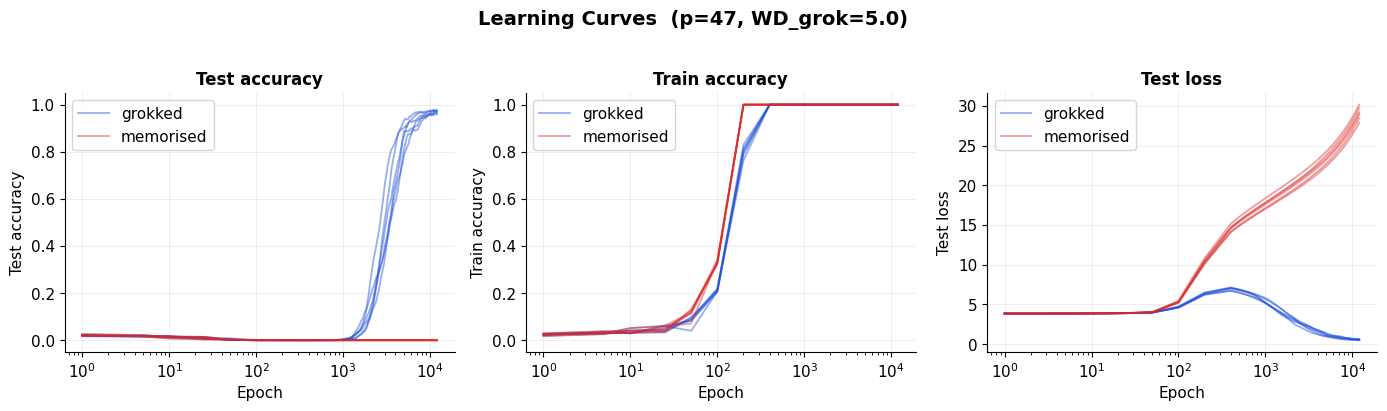

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, (metric, ylabel) in zip(axes, [
    ('test_acc',  'Test accuracy'),
    ('train_acc', 'Train accuracy'),
    ('test_loss', 'Test loss'),
]):
    for cond in ('grokked', 'memorised'):
        for j, run in enumerate(runs[cond]):
            h = run['history']
            ax.plot(h['epoch'], h[metric],
                    color=C[cond], alpha=0.45, lw=1.3,
                    label=cond if j == 0 else None)
    ax.set_xscale('log'); ax.set_xlabel('Epoch')
    ax.set_ylabel(ylabel); ax.set_title(ylabel)
    if 'acc' in metric: ax.set_ylim(-0.05, 1.05)
    ax.legend()

fig.suptitle(f'Learning Curves  (p={P}, WD_grok={WD_GROK})',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig_learning_curves.png')
plt.show()

## §5 — Computing Persistent Homology

For every checkpoint, compute H₀ and H₁ persistence diagrams for layer **W2** (128×128). This is the primary TDA object — square, dense, and tractable.

In [7]:
TDA_LAYER = 'W2'

print(f'Computing persistence diagrams for {TDA_LAYER}...')
t0 = time.time()

tda = {'grokked': [], 'memorised': []}

for cond in ('grokked', 'memorised'):
    for ri, run in enumerate(runs[cond]):
        run_tda = []
        for epoch in sorted(run['checkpoints']):
            W    = run['checkpoints'][epoch]['weights'][TDA_LAYER]
            dgms = compute_ph(W, max_dim=1)
            rec  = summarise(dgms)
            rec['epoch'] = epoch
            rec['dgms']  = dgms
            run_tda.append(rec)
        tda[cond].append(run_tda)
        print(f'  {cond} run {ri+1}/{N_RUNS}')

print(f'Done in {time.time()-t0:.1f}s')

Computing persistence diagrams for W2...
  grokked run 1/6
  grokked run 2/6
  grokked run 3/6
  grokked run 4/6
  grokked run 5/6
  grokked run 6/6
  memorised run 1/6
  memorised run 2/6
  memorised run 3/6
  memorised run 4/6
  memorised run 5/6
  memorised run 6/6
Done in 4.0s


## §6 — Topological Dynamics During Training

Track H₀ and H₁ persistence entropy and total persistence as training proceeds. The canonical signature:
- Early training: complexity rises as the network explores the loss landscape
- Memorisation phase: complexity plateaus at a high value
- Grokking transition: complexity changes as the network finds a compact generalising solution

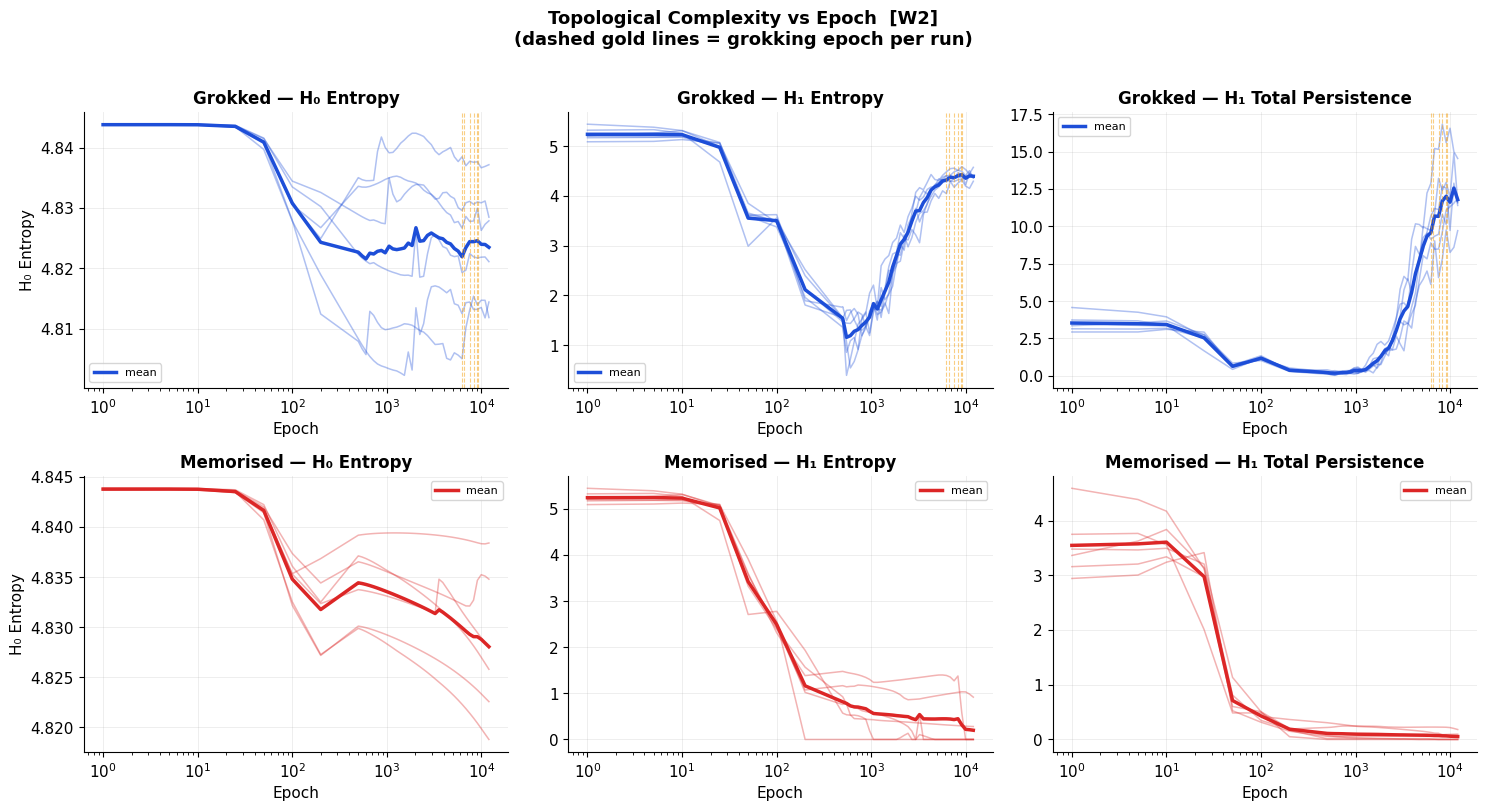

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

metric_specs = [
    ('H0_entropy',  'H₀ Entropy'),
    ('H1_entropy',  'H₁ Entropy'),
    ('H1_total',    'H₁ Total Persistence'),
]

for row, cond in enumerate(('grokked', 'memorised')):
    for col, (metric, label) in enumerate(metric_specs):
        ax  = axes[row, col]
        mat = []
        for ri, run_tda in enumerate(tda[cond]):
            eps  = [s['epoch'] for s in run_tda]
            vals = [s[metric]  for s in run_tda]
            ax.plot(eps, vals, color=C[cond], alpha=0.35, lw=1.1)
            mat.append(vals)
        mean_v = np.array(mat).mean(0)
        ax.plot(eps, mean_v, color=C[cond], lw=2.5, label='mean')

        # Mark grokking epochs for grokked condition
        if cond == 'grokked':
            for ri, run in enumerate(runs['grokked']):
                for k, (ep, acc) in enumerate(zip(run['history']['epoch'],
                                                   run['history']['test_acc'])):
                    if acc >= 0.95:
                        ax.axvline(ep, color='#f59e0b', lw=0.8, alpha=0.5, ls='--')
                        break

        ax.set_xscale('log'); ax.set_xlabel('Epoch')
        ax.set_title(f'{cond.capitalize()} — {label}')
        if col == 0: ax.set_ylabel(label)
        ax.legend(fontsize=8)

fig.suptitle(f'Topological Complexity vs Epoch  [{TDA_LAYER}]\n(dashed gold lines = grokking epoch per run)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('fig_tda_dynamics.png')
plt.show()

## §7 — Betti Number Trajectories

At a fixed filtration threshold (median pairwise distance in the final grokked W₂), track β₀ and β₁ throughout training.

Betti threshold: 2.8651


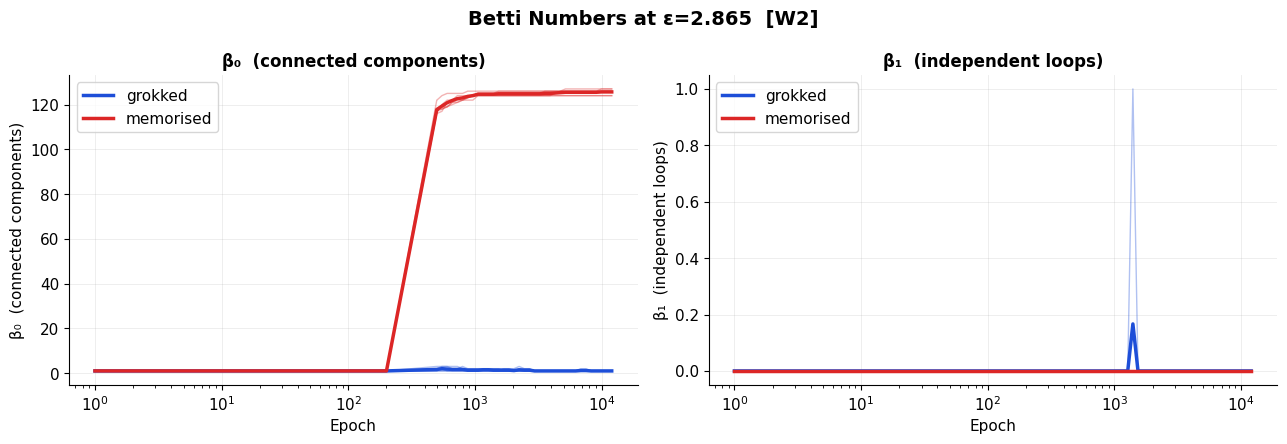

In [9]:
# Threshold = median pairwise distance of final grokked W2
W_ref  = runs['grokked'][0]['checkpoints'][max(runs['grokked'][0]['checkpoints'])]['weights'][TDA_LAYER]
D_ref  = cdist(W_ref, W_ref, 'euclidean')
THRESH = float(np.median(D_ref[D_ref > 0]))
print(f'Betti threshold: {THRESH:.4f}')

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

for ax, (dim, label) in zip(axes, [(0, 'β₀  (connected components)'),
                                    (1, 'β₁  (independent loops)')]):
    for cond in ('grokked', 'memorised'):
        all_bettis = []
        for run_tda in tda[cond]:
            eps   = [s['epoch'] for s in run_tda]
            betts = [betti_at(s['dgms'][dim], THRESH) for s in run_tda]
            ax.plot(eps, betts, color=C[cond], alpha=0.35, lw=1.0)
            all_bettis.append(betts)
        ax.plot(eps, np.array(all_bettis).mean(0),
                color=C[cond], lw=2.5, label=cond)
    ax.set_xscale('log'); ax.set_xlabel('Epoch')
    ax.set_ylabel(label); ax.set_title(label); ax.legend()

fig.suptitle(f'Betti Numbers at ε={THRESH:.3f}  [{TDA_LAYER}]',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_betti_trajectories.png')
plt.show()

## §8 — Grokking Transition: Topological Snapshots

Find the epoch where test accuracy first exceeds 95% and inspect persistence diagrams in a window around it.

Grokking at epoch ≈ 6600  |  snapshots: [5174, 5681, 6237, 6848, 7519, 8256, 9065]


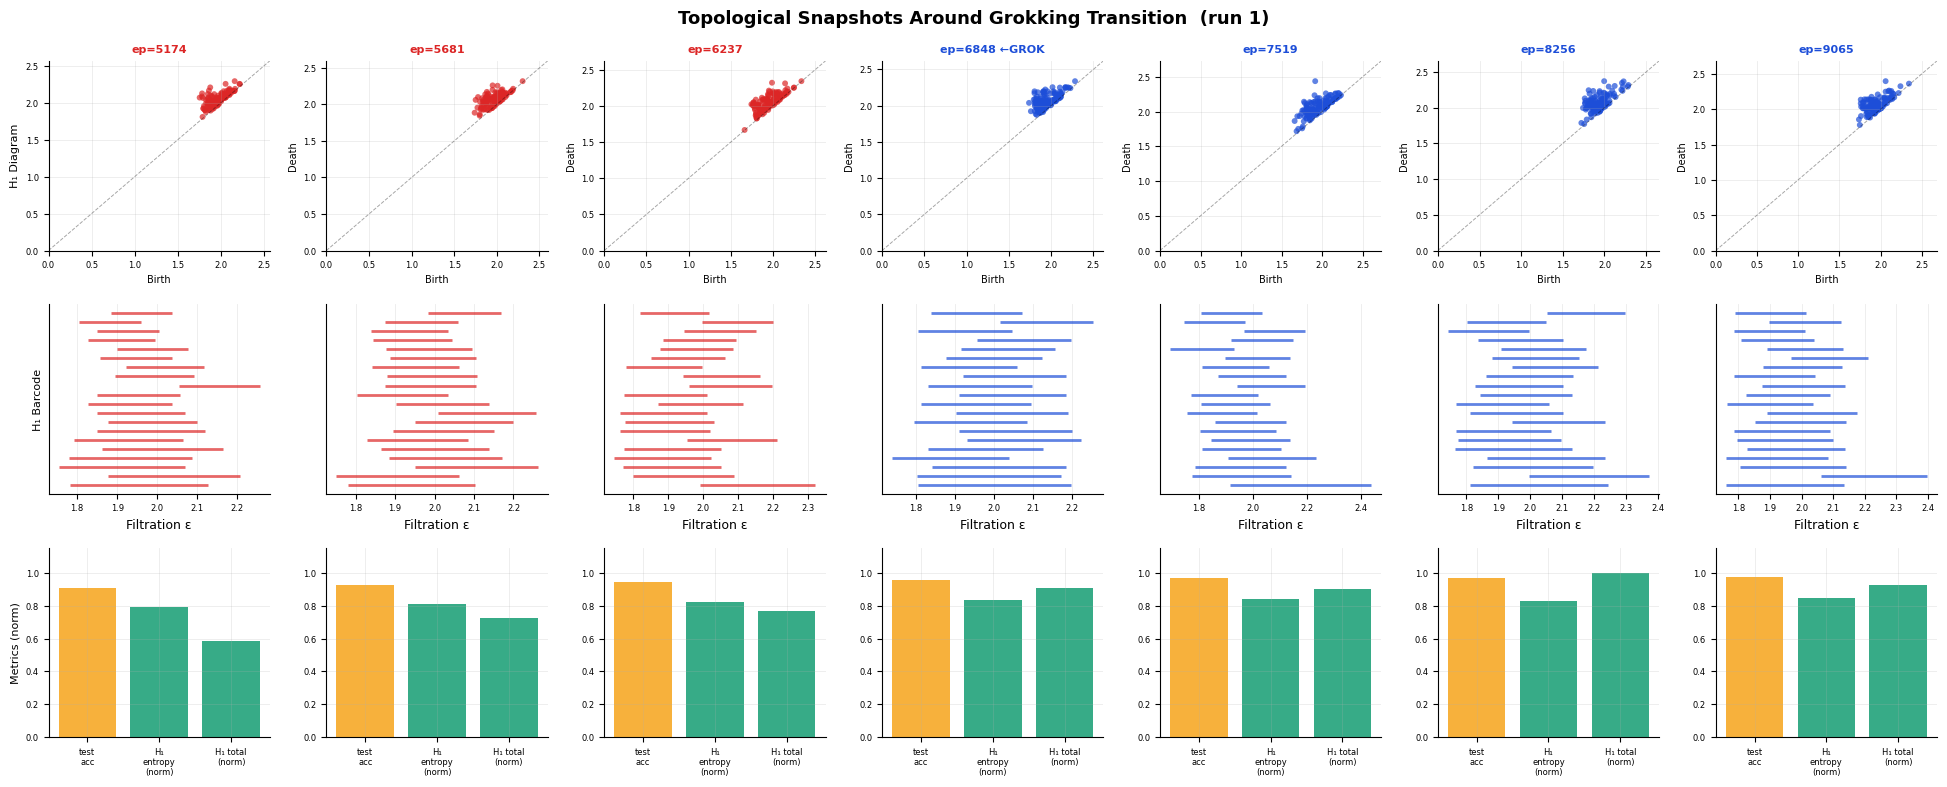

In [10]:
def grok_epoch(history, threshold=0.95):
    for ep, acc in zip(history['epoch'], history['test_acc']):
        if acc >= threshold:
            return ep
    return None

grok_ri = next((i for i, r in enumerate(runs['grokked'])
                if grok_epoch(r['history']) is not None), None)

if grok_ri is None:
    print('No run reached test_acc ≥ 95% — try increasing N_EPOCHS.')
else:
    grok_ep = grok_epoch(runs['grokked'][grok_ri]['history'])
    run_tda = tda['grokked'][grok_ri]
    all_eps = [s['epoch'] for s in run_tda]

    after_i  = next((i for i, e in enumerate(all_eps) if e >= grok_ep), len(all_eps)-1)
    snap_ids = list(range(max(0, after_i-3), min(len(all_eps), after_i+4)))
    snap_eps = [all_eps[i] for i in snap_ids]
    print(f'Grokking at epoch ≈ {grok_ep}  |  snapshots: {snap_eps}')

    n = len(snap_ids)
    fig, axes = plt.subplots(3, n, figsize=(2.8*n, 8))
    run_hist  = runs['grokked'][grok_ri]['history']

    for col, si in enumerate(snap_ids):
        snap  = run_tda[si]
        ep    = snap['epoch']
        after = ep >= grok_ep
        clr   = C['grokked'] if after else C['memorised']
        tag   = ' ←GROK' if ep == all_eps[after_i] else ''

        # Row 0: H1 persistence diagram
        ax0 = axes[0, col]
        fin = snap['dgms'][1][np.isfinite(snap['dgms'][1][:, 1])]
        if len(fin):
            lim = fin.max() * 1.12
            ax0.scatter(fin[:, 0], fin[:, 1], s=18, c=clr, alpha=0.7, edgecolors='none')
            ax0.plot([0, lim], [0, lim], 'k--', lw=0.7, alpha=0.35)
            ax0.set_xlim(0, lim); ax0.set_ylim(0, lim)
        ax0.set_title(f'ep={ep}{tag}', fontsize=8, color=clr, fontweight='bold')
        ax0.tick_params(labelsize=6)
        ax0.set_xlabel('Birth', fontsize=7); ax0.set_ylabel('Death', fontsize=7)

        # Row 1: H1 barcode
        ax1 = axes[1, col]
        plot_barcode(snap['dgms'][1], ax1, colour=clr, max_bars=20)
        ax1.tick_params(labelsize=6)

        # Row 2: scalar summary bars
        ax2  = axes[2, col]
        near = min(range(len(run_hist['epoch'])),
                   key=lambda k: abs(run_hist['epoch'][k] - ep))
        te_acc = run_hist['test_acc'][near]
        h1_ent = snap['H1_entropy']
        # Normalise total persistence to [0,1] for display
        all_tots = [s['H1_total'] for s in run_tda]
        h1_tot_n = snap['H1_total'] / (max(all_tots) + 1e-9)
        ax2.bar(['test\nacc', 'H₁\nentropy\n(norm)', 'H₁ total\n(norm)'],
                [te_acc,
                 h1_ent / (max(s['H1_entropy'] for s in run_tda) + 1e-9),
                 h1_tot_n],
                color=[C['accent'], C['h1'], C['h1']], alpha=0.8)
        ax2.set_ylim(0, 1.15); ax2.tick_params(labelsize=6)

    axes[0, 0].set_ylabel('H₁ Diagram', fontsize=8)
    axes[1, 0].set_ylabel('H₁ Barcode', fontsize=8)
    axes[2, 0].set_ylabel('Metrics (norm)', fontsize=8)
    fig.suptitle(f'Topological Snapshots Around Grokking Transition  (run {grok_ri+1})',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig('fig_grokking_transition.png')
    plt.show()

## §9 — Persistence Diagrams at Convergence

H₀ and H₁ diagrams for all runs at the final checkpoint. S = persistence entropy.

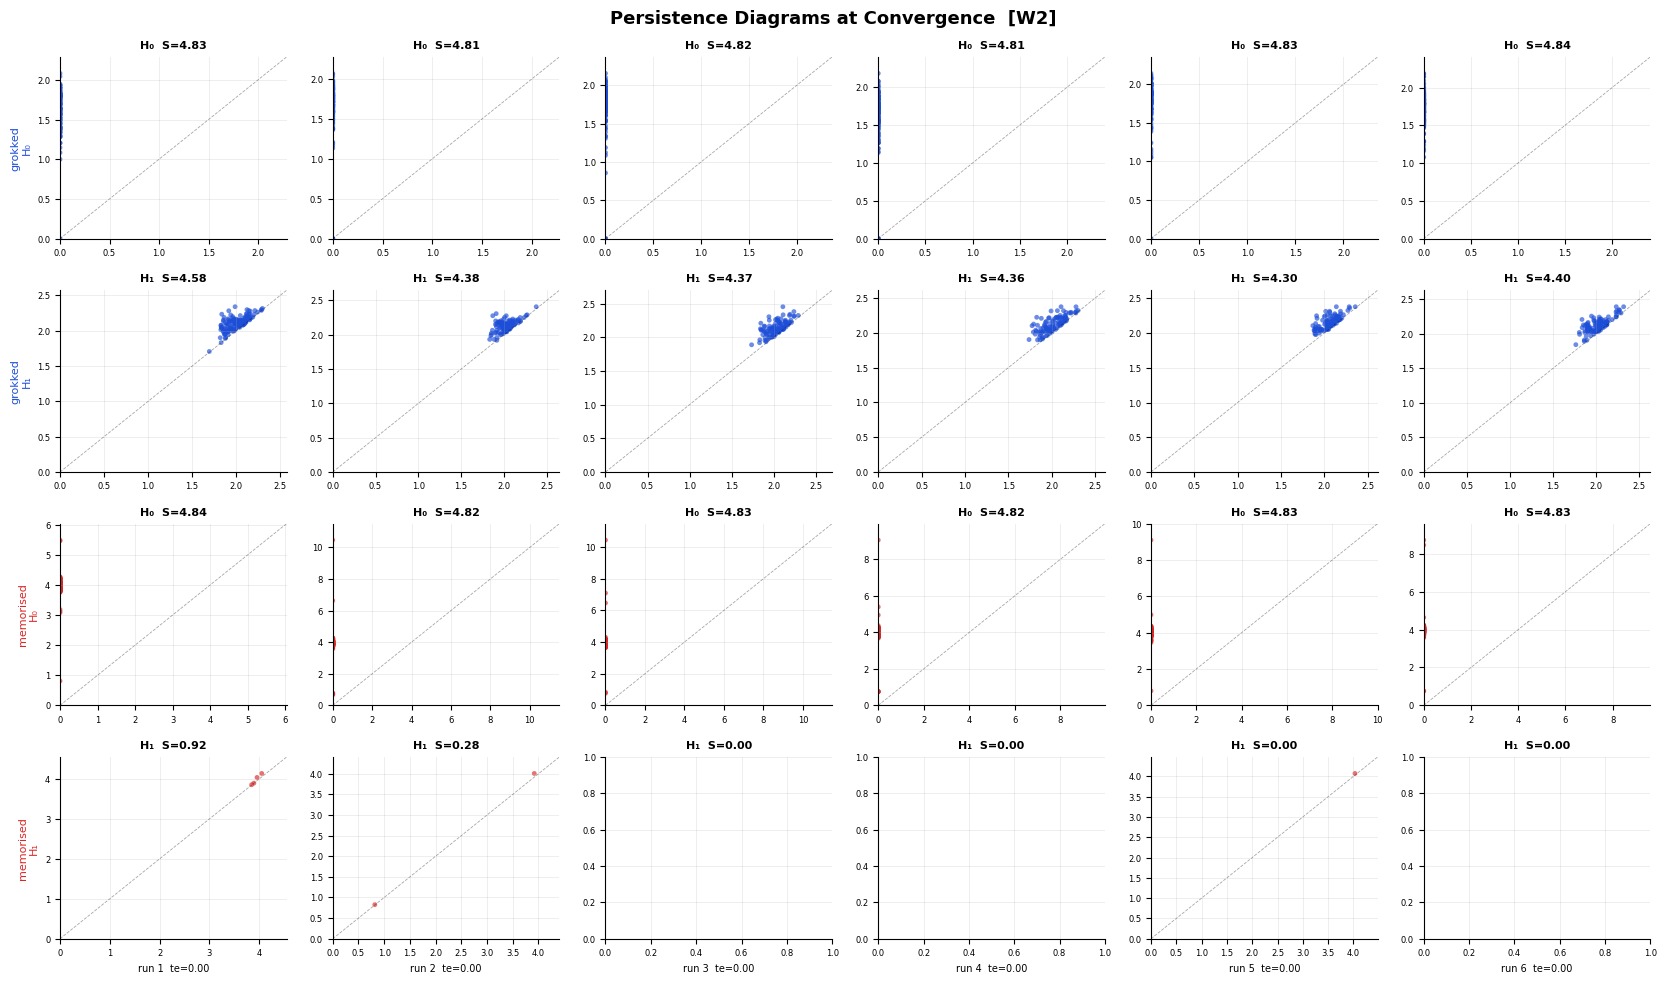

In [11]:
n_show = N_RUNS
fig, axes = plt.subplots(4, n_show, figsize=(2.8*n_show, 10))

row_specs = [
    ('grokked',   0, 'H₀'),
    ('grokked',   1, 'H₁'),
    ('memorised', 0, 'H₀'),
    ('memorised', 1, 'H₁'),
]

for col in range(n_show):
    for row, (cond, dim, dimlab) in enumerate(row_specs):
        ax   = axes[row, col]
        snap = tda[cond][col][-1]
        dgm  = snap['dgms'][dim]
        fin  = dgm[np.isfinite(dgm[:, 1])]
        ent  = snap[f'H{dim}_entropy']
        te   = runs[cond][col]['history']['test_acc'][-1]
        if len(fin):
            lim = fin.max() * 1.1
            ax.scatter(fin[:, 0], fin[:, 1], s=12, c=C[cond],
                       alpha=0.65, edgecolors='none')
            ax.plot([0, lim], [0, lim], 'k--', lw=0.6, alpha=0.35)
            ax.set_xlim(0, lim); ax.set_ylim(0, lim)
        ax.set_title(f'{dimlab}  S={ent:.2f}', fontsize=8)
        ax.tick_params(labelsize=6)
        if col == 0:
            ax.set_ylabel(f'{cond}\n{dimlab}', fontsize=8, color=C[cond])
        if row == 3:
            ax.set_xlabel(f'run {col+1}  te={te:.2f}', fontsize=7)

fig.suptitle(f'Persistence Diagrams at Convergence  [{TDA_LAYER}]',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_persistence_diagrams.png')
plt.show()

## §10 — Wasserstein Distances & MDS Embedding

Pairwise Wasserstein-1 distances between H₁ diagrams of all final-checkpoint networks. If grokked and memorised solutions are topologically distinct, cross-condition distances should exceed within-condition distances. MDS embeds the distance matrix in 2D.

Computing 12×12 Wasserstein matrix...
Done in 0.1s


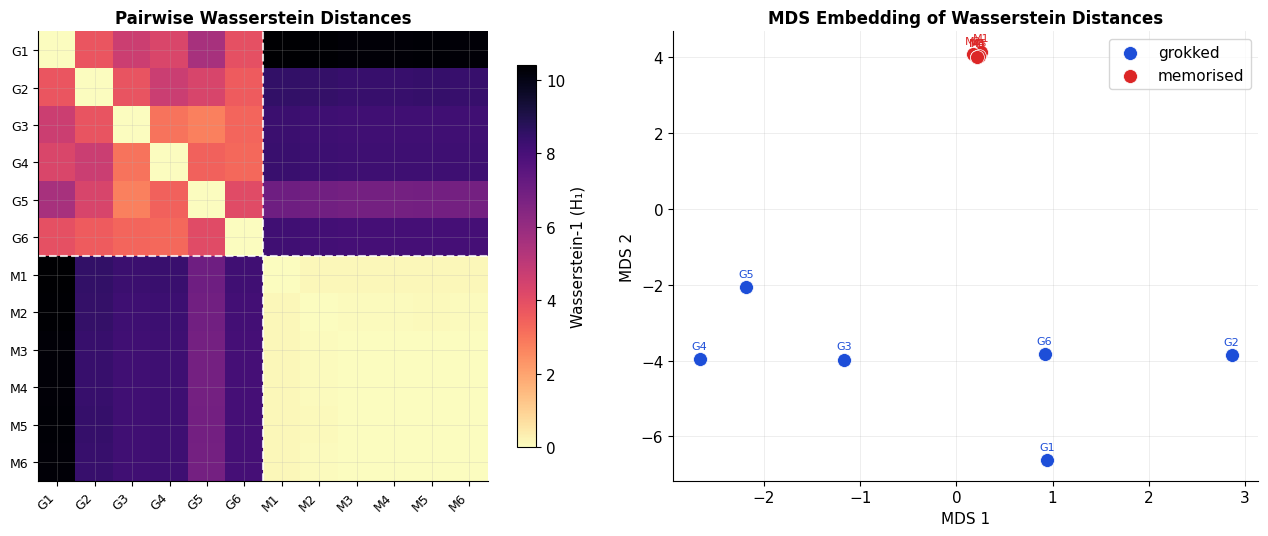

Mean intra-Grokked  distance: 3.8975
Mean intra-Memorised distance: 0.0869
Mean cross-condition distance: 8.3720
Cross/intra ratio: 2.15  (>1 means conditions are topologically separated)


In [12]:
final_dgms   = []
final_labels = []

for cond in ('grokked', 'memorised'):
    for ri, run_tda in enumerate(tda[cond]):
        final_dgms.append(run_tda[-1]['dgms'][1])
        final_labels.append(cond)

N_tot = len(final_dgms)
W_mat = np.zeros((N_tot, N_tot))

print(f'Computing {N_tot}×{N_tot} Wasserstein matrix...')
t0 = time.time()
for i in range(N_tot):
    for j in range(i+1, N_tot):
        d = wasserstein(final_dgms[i], final_dgms[j])
        W_mat[i, j] = W_mat[j, i] = d
print(f'Done in {time.time()-t0:.1f}s')

n_g  = sum(1 for l in final_labels if l == 'grokked')
tklb = [f'G{i+1}' for i in range(n_g)] + [f'M{i+1}' for i in range(N_tot - n_g)]

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

# Heatmap
ax = axes[0]
im = ax.imshow(W_mat, cmap='magma_r')
plt.colorbar(im, ax=ax, label='Wasserstein-1 (H₁)', shrink=0.85)
ax.set_xticks(range(N_tot)); ax.set_yticks(range(N_tot))
ax.set_xticklabels(tklb, rotation=45, ha='right', fontsize=9)
ax.set_yticklabels(tklb, fontsize=9)
ax.axvline(n_g - 0.5, color='white', lw=1.5, ls='--', alpha=0.8)
ax.axhline(n_g - 0.5, color='white', lw=1.5, ls='--', alpha=0.8)
ax.set_title('Pairwise Wasserstein Distances')

# MDS
ax2  = axes[1]
emb  = MDS(n_components=2, dissimilarity='precomputed', random_state=0).fit_transform(W_mat)
for cond in ('grokked', 'memorised'):
    idx = [i for i, l in enumerate(final_labels) if l == cond]
    ax2.scatter(emb[idx, 0], emb[idx, 1],
                c=C[cond], s=100, label=cond, edgecolors='white', lw=0.5, zorder=3)
    for i in idx:
        ax2.annotate(tklb[i], emb[i], fontsize=8, ha='center', va='bottom',
                     xytext=(0, 6), textcoords='offset points', color=C[cond])
ax2.set_title('MDS Embedding of Wasserstein Distances')
ax2.set_xlabel('MDS 1'); ax2.set_ylabel('MDS 2'); ax2.legend()

plt.tight_layout()
plt.savefig('fig_wasserstein.png')
plt.show()

G = np.array([i for i, l in enumerate(final_labels) if l == 'grokked'])
M = np.array([i for i, l in enumerate(final_labels) if l == 'memorised'])
gg = W_mat[np.ix_(G, G)]; gg = gg[gg > 0].mean()
mm = W_mat[np.ix_(M, M)]; mm = mm[mm > 0].mean()
gm = W_mat[np.ix_(G, M)].mean()
print(f'Mean intra-Grokked  distance: {gg:.4f}')
print(f'Mean intra-Memorised distance: {mm:.4f}')
print(f'Mean cross-condition distance: {gm:.4f}')
ratio = gm / max(gg, mm)
print(f'Cross/intra ratio: {ratio:.2f}  (>1 means conditions are topologically separated)')

## §11 — Hierarchical Clustering

Agglomerative clustering (Ward linkage) on the Wasserstein distance matrix. If topology separates conditions cleanly, the dendrogram should show two distinct subtrees.

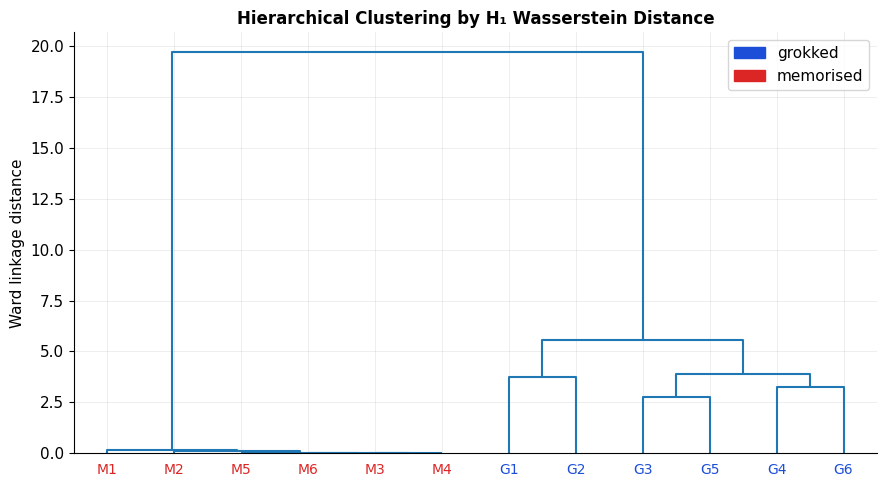

In [13]:
# Condense upper triangle for scipy
upper = W_mat[np.triu_indices(N_tot, k=1)]
Z     = linkage(upper, method='ward')

fig, ax = plt.subplots(figsize=(max(9, N_tot*0.7), 5))
dend    = dendrogram(Z, labels=tklb, ax=ax,
                     leaf_font_size=10, color_threshold=0)
for lbl, leaf in zip(ax.get_xticklabels(), dend['leaves']):
    lbl.set_color(C[final_labels[leaf]])

patches = [mpatches.Patch(color=C[c], label=c) for c in ('grokked', 'memorised')]
ax.legend(handles=patches, loc='upper right')
ax.set_title('Hierarchical Clustering by H₁ Wasserstein Distance',
             fontsize=12, fontweight='bold')
ax.set_ylabel('Ward linkage distance')
plt.tight_layout()
plt.savefig('fig_dendrogram.png')
plt.show()

## §12 — Layer-wise Topology Profile

Compare H₀ and H₁ entropy across all three layers at convergence. Does topology vary systematically with depth?

Computing layer-wise persistence...
  grokked W1  H1_ent=4.546±0.356
  grokked W2  H1_ent=4.397±0.086
  grokked W3  H1_ent=4.340±0.041
  memorised W1  H1_ent=4.732±0.142
  memorised W2  H1_ent=0.200±0.337
  memorised W3  H1_ent=3.715±0.156


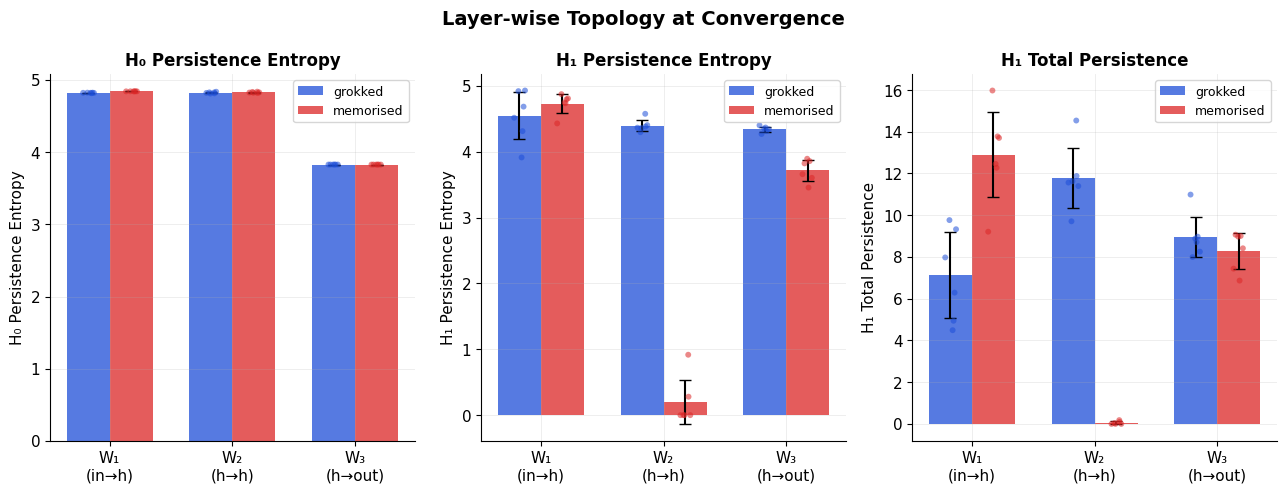

In [17]:
print('Computing layer-wise persistence...')
layer_data = {}   # (cond, layer, metric) → list over runs

for cond in ('grokked', 'memorised'):
    for layer in ('W1', 'W2', 'W3'):
        ents_h0, ents_h1, tots_h1 = [], [], []
        for run in runs[cond]:
            last = max(run['checkpoints'])
            W    = run['checkpoints'][last]['weights'][layer]
            dgms = compute_ph(W, max_dim=1)
            ents_h0.append(persistence_entropy(dgms[0]))
            ents_h1.append(persistence_entropy(dgms[1]))
            tots_h1.append(total_persistence(dgms[1]))
        layer_data[(cond, layer, 'H0_entropy')] = ents_h0
        layer_data[(cond, layer, 'H1_entropy')] = ents_h1
        layer_data[(cond, layer, 'H1_total')]   = tots_h1
        print(f'  {cond} {layer}  H1_ent={np.mean(ents_h1):.3f}±{np.std(ents_h1):.3f}')

layers = ['W1', 'W2', 'W3']
xlabs  = ['W₁\n(in→h)', 'W₂\n(h→h)', 'W₃\n(h→out)']

fig, axes = plt.subplots(1, 3, figsize=(13, 5))
x, width  = np.arange(3), 0.35

for ax, (metric, mlabel) in zip(axes, [
    ('H0_entropy', 'H₀ Persistence Entropy'),
    ('H1_entropy', 'H₁ Persistence Entropy'),
    ('H1_total',   'H₁ Total Persistence'),
]):
    for bi, (cond, offset) in enumerate(zip(('grokked','memorised'), [-width/2, width/2])):
        means = [np.mean(layer_data[(cond, l, metric)]) for l in layers]
        stds  = [np.std( layer_data[(cond, l, metric)]) for l in layers]
        ax.bar(x+offset, means, width, yerr=stds, color=C[cond], alpha=0.75,
               label=cond, capsize=4, error_kw={'lw': 1.5})
        rng = np.random.default_rng(42)
        for li, l in enumerate(layers):
            v = layer_data[(cond, l, metric)]
            ax.scatter(x[li]+offset+rng.uniform(-0.05, 0.05, len(v)), v,
                       c=C[cond], s=18, alpha=0.55, zorder=4, edgecolors='none')
    ax.set_xticks(x); ax.set_xticklabels(xlabs)
    ax.set_ylabel(mlabel); ax.set_title(mlabel); ax.legend(fontsize=9)

fig.suptitle('Layer-wise Topology at Convergence', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_layerwise.png')
plt.show()

## §13 — Statistical Comparison

Mann–Whitney U tests (non-parametric, suitable for small N) on TDA metrics at convergence.

In [18]:
print('=' * 70)
print(f'Statistical comparison: Grokked vs Memorised  [{TDA_LAYER} at convergence]')
print('=' * 70)
print(f'{"Metric":<22}  {"Grokked (μ±σ)":>18}  {"Memorised (μ±σ)":>18}  {"p":>8}  Sig')
print('-' * 70)

for metric in ['H0_entropy','H1_entropy','H0_total','H1_total',
               'H0_energy','H1_energy','H0_max','H1_max','H0_n','H1_n']:
    g = [tda['grokked'][ri][-1][metric]   for ri in range(N_RUNS)]
    m = [tda['memorised'][ri][-1][metric] for ri in range(N_RUNS)]
    gm, gs = np.mean(g), np.std(g)
    mm, ms = np.mean(m), np.std(m)
    p = mannwhitneyu(g, m, alternative='two-sided')[1] if len(set(g+m)) > 1 else 1.0
    sig = '***' if p<0.001 else ('**' if p<0.01 else ('*' if p<0.05 else ('.' if p<0.1 else 'ns')))
    print(f'{metric:<22}  {gm:>7.3f}±{gs:<8.3f}  {mm:>7.3f}±{ms:<8.3f}  {p:>8.4f}  {sig}')

print('=' * 70)
print('Codes: *** p<0.001  ** p<0.01  * p<0.05  . p<0.1  ns')

Statistical comparison: Grokked vs Memorised  [W2 at convergence]
Metric                       Grokked (μ±σ)     Memorised (μ±σ)         p  Sig
----------------------------------------------------------------------
H0_entropy                4.823±0.009       4.828±0.007       0.4848  ns
H1_entropy                4.397±0.086       0.200±0.337       0.0043  **
H0_total                214.880±7.228     504.760±4.899       0.0022  **
H1_total                 11.786±1.421       0.053±0.067       0.0048  **
H0_energy               374.007±23.673    2068.050±33.596      0.0022  **
H1_energy                 2.021±0.313       0.004±0.005       0.0048  **
H0_max                    2.137±0.047       8.877±1.659       0.0022  **
H1_max                    0.378±0.025       0.036±0.040       0.0048  **
H0_n                    128.000±0.000     128.000±0.000       1.0000  ns
H1_n                    109.167±11.187      1.167±1.462       0.0048  **
Codes: *** p<0.001  ** p<0.01  * p<0.05  . p<0.1  ns


## §14 — PCA of Weight Trajectories

Embed the flattened W₂ weight vector at each checkpoint into 2D via PCA. This shows the *geometric path* each training run takes through parameter space.

PC1: 14.2%   PC2: 13.8%


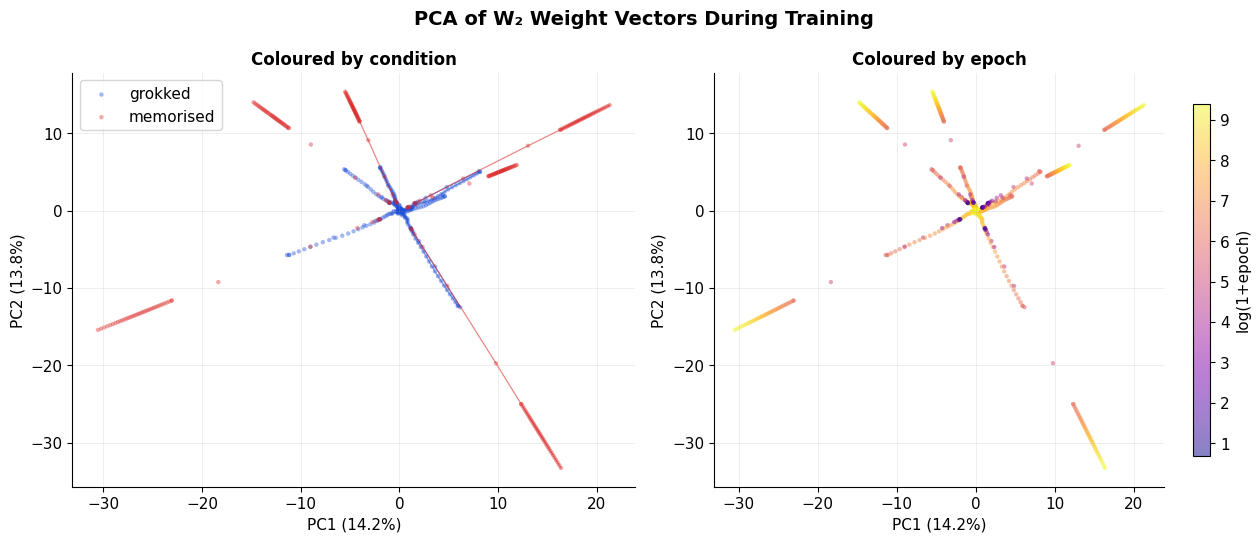

In [16]:
all_vecs, meta = [], []
for cond in ('grokked', 'memorised'):
    for ri, run in enumerate(runs[cond]):
        for ep in sorted(run['checkpoints']):
            all_vecs.append(run['checkpoints'][ep]['weights']['W2'].flatten())
            meta.append({'cond': cond, 'run': ri, 'epoch': ep})

all_vecs = np.array(all_vecs)
pca2     = PCA(n_components=2)
emb2d    = pca2.fit_transform(all_vecs)
var      = pca2.explained_variance_ratio_
print(f'PC1: {100*var[0]:.1f}%   PC2: {100*var[1]:.1f}%')

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

for ax, color_by in zip(axes, ['condition', 'epoch']):
    if color_by == 'condition':
        for cond in ('grokked', 'memorised'):
            idx = [i for i, m in enumerate(meta) if m['cond'] == cond]
            ax.scatter(emb2d[idx, 0], emb2d[idx, 1],
                       c=C[cond], s=10, alpha=0.4, label=cond, edgecolors='none')
            for ri in range(min(3, N_RUNS)):
                r_idx = sorted([i for i in idx if meta[i]['run']==ri],
                               key=lambda i: meta[i]['epoch'])
                ax.plot(emb2d[r_idx, 0], emb2d[r_idx, 1],
                        color=C[cond], lw=0.9, alpha=0.55)
        ax.legend(); ax.set_title('Coloured by condition')
    else:
        sc = ax.scatter(emb2d[:, 0], emb2d[:, 1],
                        c=np.log1p([m['epoch'] for m in meta]),
                        cmap='plasma', s=10, alpha=0.5, edgecolors='none')
        plt.colorbar(sc, ax=ax, label='log(1+epoch)', shrink=0.85)
        ax.set_title('Coloured by epoch')
    ax.set_xlabel(f'PC1 ({100*var[0]:.1f}%)')
    ax.set_ylabel(f'PC2 ({100*var[1]:.1f}%)')

fig.suptitle('PCA of W₂ Weight Vectors During Training',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_pca_trajectory.png')
plt.show()

## §15 — TDA Metrics vs Test Accuracy

Does topological complexity at convergence predict generalisation? Scatter plot with Spearman correlation.

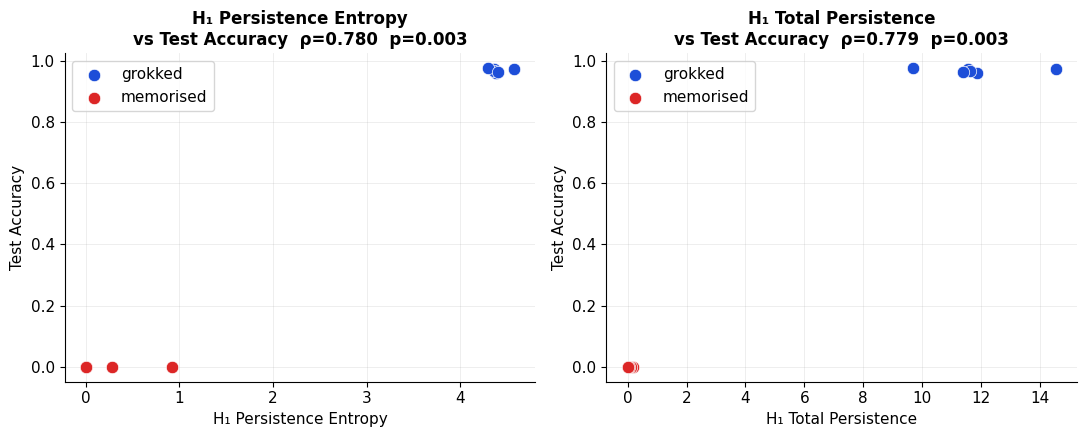

In [19]:
ent_vals, tot_vals, acc_vals, cond_vals = [], [], [], []
for cond in ('grokked', 'memorised'):
    for ri in range(N_RUNS):
        ent_vals.append(tda[cond][ri][-1]['H1_entropy'])
        tot_vals.append(tda[cond][ri][-1]['H1_total'])
        acc_vals.append(runs[cond][ri]['history']['test_acc'][-1])
        cond_vals.append(cond)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

for ax, (xvals, xlabel) in zip(axes, [
    (ent_vals, 'H₁ Persistence Entropy'),
    (tot_vals, 'H₁ Total Persistence'),
]):
    for cond in ('grokked', 'memorised'):
        idx = [i for i, c in enumerate(cond_vals) if c == cond]
        ax.scatter([xvals[i] for i in idx], [acc_vals[i] for i in idx],
                   c=C[cond], s=80, label=cond, edgecolors='white', lw=0.5, zorder=3)
    rho, p = spearmanr(xvals, acc_vals)
    ax.set_xlabel(xlabel); ax.set_ylabel('Test Accuracy')
    ax.set_title(f'{xlabel}\nvs Test Accuracy  ρ={rho:.3f}  p={p:.3f}')
    ax.legend()

plt.tight_layout()
plt.savefig('fig_tda_vs_acc.png')
plt.show()

## §16 — Multi-layer Barcodes

H₁ persistence barcodes for all three layers of one grokked and one memorised network. Bar length = feature lifetime; longer bars = topologically more significant.

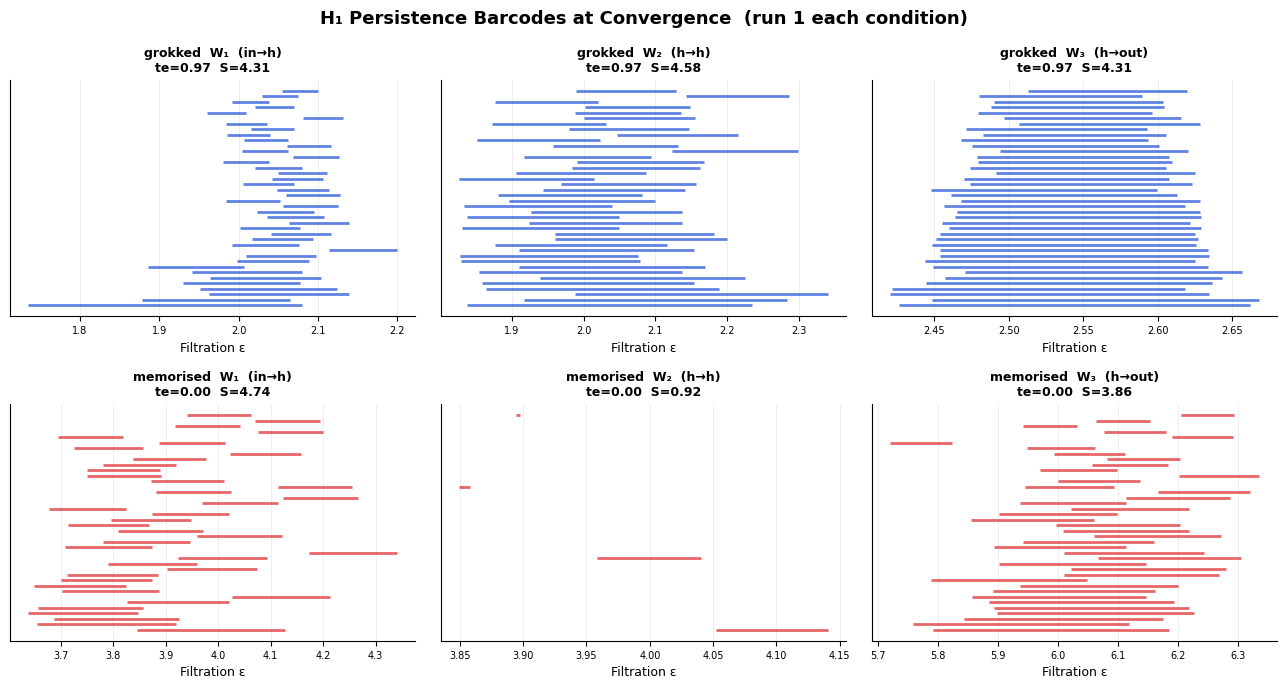

In [20]:
fig, axes = plt.subplots(2, 3, figsize=(13, 7))
layers = ['W1', 'W2', 'W3']
xlabs  = ['W₁  (in→h)', 'W₂  (h→h)', 'W₃  (h→out)']

for row, cond in enumerate(('grokked', 'memorised')):
    run     = runs[cond][0]
    last_ep = max(run['checkpoints'])
    te_acc  = run['history']['test_acc'][-1]
    for col, (layer, xlab) in enumerate(zip(layers, xlabs)):
        ax  = axes[row, col]
        W   = run['checkpoints'][last_ep]['weights'][layer]
        dgm = compute_ph(W, max_dim=1)[1]
        ent = persistence_entropy(dgm)
        plot_barcode(dgm, ax, colour=C[cond], max_bars=40,
                     label=f'{cond}  {xlab}\nte={te_acc:.2f}  S={ent:.2f}')
        ax.tick_params(labelsize=7)

fig.suptitle('H₁ Persistence Barcodes at Convergence  (run 1 each condition)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_barcodes.png')
plt.show()

## §17 — Summary & Extensions

### What this notebook measured

| Section | Analysis | Key question |
|---|---|---|
| §6  | Topological dynamics | Does complexity rise then fall? Is the grokking epoch visible? |
| §7  | Betti trajectories | How do β₀, β₁ evolve at a fixed scale? |
| §8  | Grokking transition | Is the phase transition visible in the persistence diagram? |
| §9  | Diagrams at convergence | Visual fingerprints of grokked vs memorised solutions |
| §10 | Wasserstein matrix + MDS | Do independently trained networks cluster topologically? |
| §11 | Hierarchical clustering | Do conditions self-separate in topology space? |
| §12 | Layer-wise profile | Does topology vary with depth? |
| §13 | Statistical tests | Which TDA metrics significantly differ between conditions? |
| §14 | PCA trajectories | What geometric paths do conditions take through weight space? |
| §15 | TDA vs accuracy | Does topological complexity predict generalisation? |
| §16 | Multi-layer barcodes | How do all three layers look together? |

---

### Extensions

**TDA-guided pruning.** For each layer, remove neurons whose rows contribute only low-persistence (short-lived H₁) features. Compare accuracy drop to magnitude-based pruning at the same compression ratio. The prediction: TDA pruning should preserve function better because it respects relational structure, not just weight magnitudes.

**Topological distillation loss.** Train a smaller network with an auxiliary Wasserstein loss:
$$\mathcal{L} = \mathcal{L}_{\text{task}} + \lambda \cdot d_W(\text{Dgm}(W), \text{Dgm}(W_{\text{teacher}}))$$
This is differentiable via subgradients of persistent homology (e.g. TopologyLayer from Giotto-TDA).

**Multiple operations.** Extend to other modular arithmetic tasks (multiplication, composition) and ask whether the topological fingerprint encodes the algebraic structure of the operation.

**Sublevel-set filtration.** Instead of VR on rows, use the weight values as a function on the neuron connectivity graph with sublevel-set persistence — this is sensitive to the *distribution* of weight magnitudes rather than their geometry.

**Connection to amplitude retrieval.** Apply this pipeline to the MLP amplitude encoder in your CLIP system: ask whether the gauge and gravity embedding clusters have different intrinsic topology, and whether the double-copy axis (mean displacement vector between cluster centroids) is a topologically distinguished direction in W₂ weight space.